<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment9ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##For this assignment, I chose the Mall Customer Segmentation dataset from Kaggle because it is perfectly suited for unsupervised learning tasks such as clustering and dimensionality reduction. The dataset includes features like age, annual income, spending score, and gender, which allow me to perform meaningful customer segmentation using techniques such as K‑Means and hierarchical clustering. It also supports all required preprocessing steps, including scaling, encoding, and normalization, and it produces clear, interpretable visualizations when applying PCA or t‑SNE. Additionally, this dataset aligns well with real‑world business applications, making it an ideal choice for discussing deployment strategies, monitoring challenges, and model maintenance in a production environment.

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer



In [2]:
#Load the dataset
df = pd.read_csv('customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
#data types
print(df.dtypes)

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


In [5]:
#data shapes
print(df.shape)

(2240, 29)


In [6]:
# Separate numeric and categorical variables correctly

# X = all features except the target columns
X = df.drop(['Dt_Customer', 'Education', 'Marital_Status'], axis=1)

# y_true = the target columns (if you need them for evaluation or comparison)
y_true = df[['Dt_Customer', 'Education', 'Marital_Status']]


In [7]:
# Impute missing values (though this dataset has none, it's a good practice)
x_imputer = SimpleImputer(strategy='mean')
y_true_imputed = SimpleImputer(strategy='most_frequent').fit_transform(y_true.values.reshape(-1, 1)).flatten()



In [8]:
#Apply imputers
x_imputed = x_imputer.fit_transform(X)
y_true_imputed = y_true_imputed.reshape(-1, 1)

print(x_imputed.shape)
print(y_true_imputed.shape)
print(y_true_imputed)
print(x_imputed)


(2240, 26)
(6720, 1)
[['04-09-2012']
 ['Graduation']
 ['Single']
 ...
 ['15-10-2012']
 ['PhD']
 ['Married']]
[[5.5240e+03 1.9570e+03 5.8138e+04 ... 3.0000e+00 1.1000e+01 1.0000e+00]
 [2.1740e+03 1.9540e+03 4.6344e+04 ... 3.0000e+00 1.1000e+01 0.0000e+00]
 [4.1410e+03 1.9650e+03 7.1613e+04 ... 3.0000e+00 1.1000e+01 0.0000e+00]
 ...
 [7.2700e+03 1.9810e+03 5.6981e+04 ... 3.0000e+00 1.1000e+01 0.0000e+00]
 [8.2350e+03 1.9560e+03 6.9245e+04 ... 3.0000e+00 1.1000e+01 0.0000e+00]
 [9.4050e+03 1.9540e+03 5.2869e+04 ... 3.0000e+00 1.1000e+01 1.0000e+00]]


In [9]:
#Droping null values since only small amount is missing
df.dropna(inplace=True)

In [10]:
df['TotalPurchase'] = df[['MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds']].sum(axis=1)
print("Maximum :",df['TotalPurchase'].max(),"Minimum :",df['TotalPurchase'].min())

Maximum : 2525 Minimum : 5


In [11]:
df = df[df['Income'] < 200000]

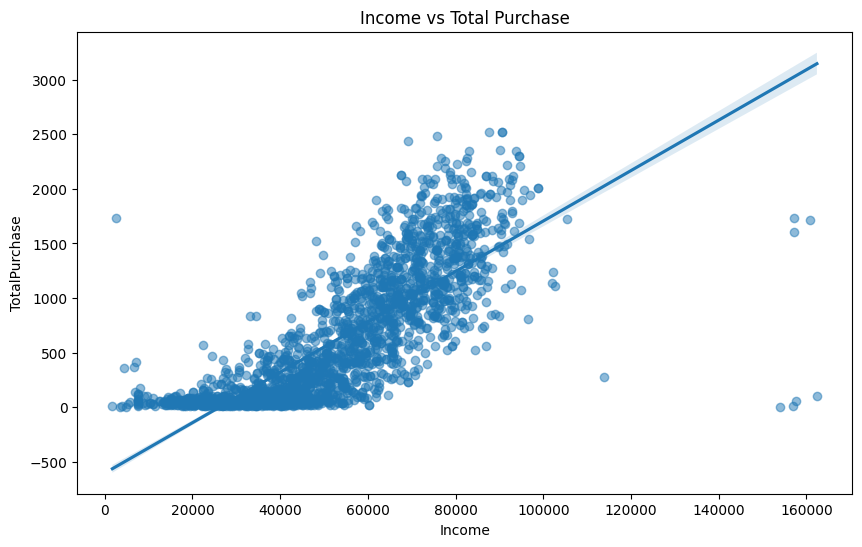

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="Income",
    y="TotalPurchase",
    robust=True,  # Minimizes the influence of extreme outliers
    scatter_kws={"alpha": 0.5},
)
plt.title("Income vs Total Purchase")
plt.show()

##The analysis reveals a positive association between annual income and spending score. This trend is expected: customers with higher incomes typically have more discretionary funds, which translate into higher purchasing activity. This aligns with standard consumer behavior theory, were purchasing power increases with income.

In [13]:
df.groupby('Education')['Income'].mean()

,Income
Education,
2n Cycle,47633.190000
Basic,20306.259259
Graduation,52169.749776
Master,52917.534247
PhD,56145.313929


In [14]:
df['Education'].value_counts()

,count
Education,
Graduation,1115
PhD,481
Master,365
2n Cycle,200
Basic,54


In [15]:
purchase_edu = df.groupby('Education')['TotalPurchase'].mean()
purchase_edu

,TotalPurchase
Education,
2n Cycle,494.930000
Basic,81.796296
Graduation,622.188341
Master,609.767123
PhD,676.733888


In [16]:
df.groupby('Education')['Income'].mean()

,Income
Education,
2n Cycle,47633.190000
Basic,20306.259259
Graduation,52169.749776
Master,52917.534247
PhD,56145.313929


In [17]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,572
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [18]:
df.groupby('Marital_Status')['Income'].mean()

,Income
Marital_Status,
Absurd,72365.500000
Alone,43789.000000
Divorced,52834.228448
Married,51724.978996
Single,50995.350318
Together,52173.120629
Widow,56481.552632
YOLO,48432.000000


In [19]:
purchase_mar = df.groupby('Marital_Status')['TotalPurchase'].mean()
purchase_mar

,TotalPurchase
Marital_Status,
Absurd,1192.500000
Alone,256.666667
Divorced,610.629310
Married,591.464411
Single,612.592357
Together,609.802448
Widow,727.960526
YOLO,424.000000


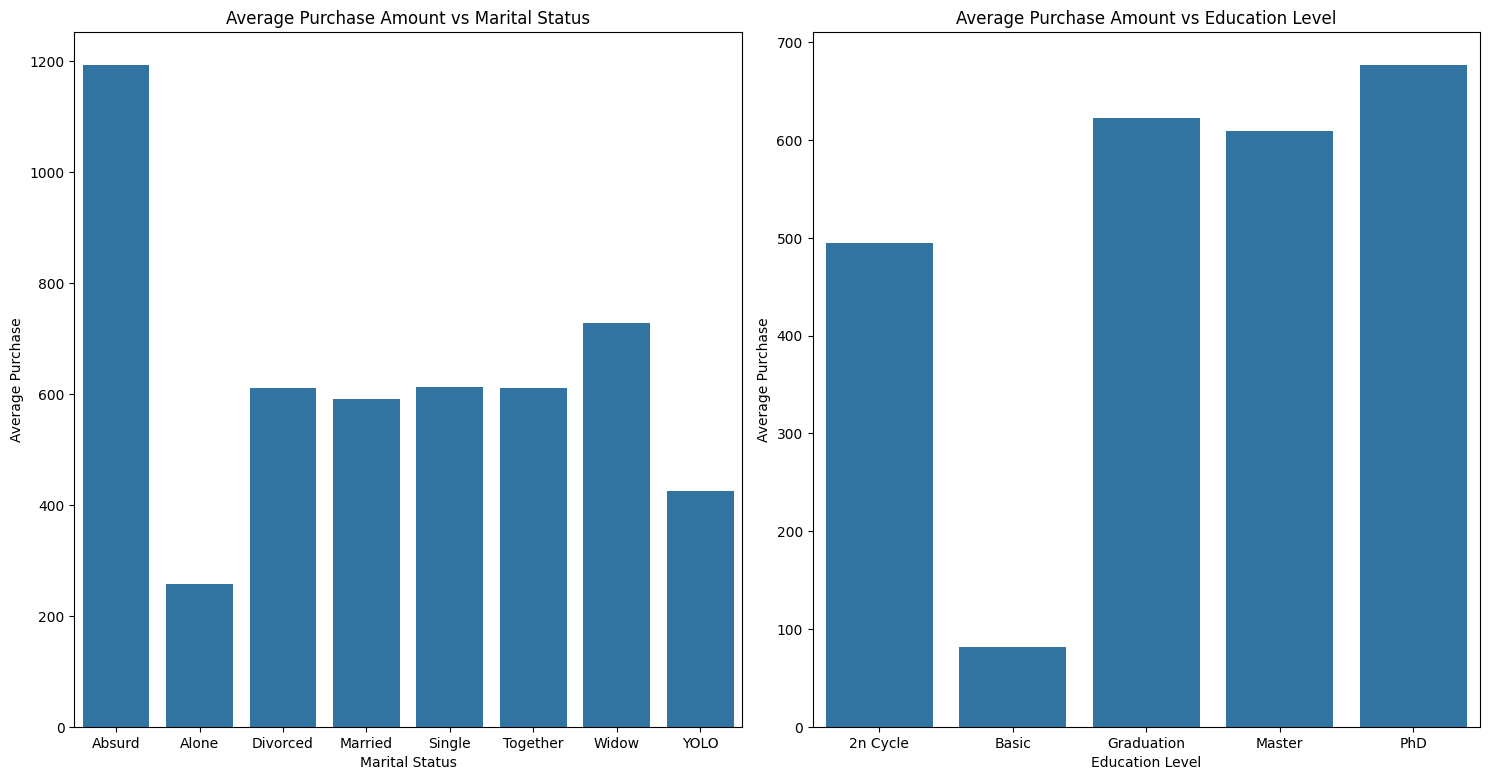

In [20]:
#plot Average purchase amount vs marital status and Average amount vs Education level
plt.figure(figsize=(15,15))
plt.subplot(2,2,1)
sns.barplot(x=purchase_mar.index,y=purchase_mar.values)
plt.title('Average Purchase Amount vs Marital Status')
plt.ylabel('Average Purchase')
plt.xlabel('Marital Status')

plt.subplot(2,2,2)
sns.barplot(x=purchase_edu.index,y=purchase_edu.values)
plt.title('Average Purchase Amount vs Education Level')
plt.ylabel('Average Purchase')
plt.xlabel('Education Level')
plt.tight_layout()
plt.show()

In [21]:
# Scale the features

# Create a working copy of the DataFrame to ensure previous operations (like dropna and TotalPurchase calculation)
# are reflected and to avoid modifying the original 'df' if not intended.
temp_df = df.copy()

# Columns to be dropped for the features used in clustering.
# 'ID' is a unique identifier and 'Dt_Customer' is a date, neither are typically used directly in KMeans.
cols_to_drop = ['ID', 'Dt_Customer']
features_df = temp_df.drop(columns=cols_to_drop, axis=1)

# Identify categorical columns that need one-hot encoding.
# From df.info(), 'Education' and 'Marital_Status' are objects and suitable for encoding.
categorical_cols_to_encode = ['Education', 'Marital_Status']

# Apply one-hot encoding to these categorical columns in features_df
X_preprocessed = pd.get_dummies(features_df, columns=categorical_cols_to_encode, drop_first=True)

# 'X' is often used to hold the feature matrix, and here we use it for column names as well.
X = X_preprocessed

# Scale the numerical features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_preprocessed), columns=X.columns)

In [22]:
# Determine the optimal number of clusters using Elbow Method and Silhouette Score
inertia_list = []
silhouette_list = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_) #km.inertia_ → lower inertia indicates tighter clusters.
    silhouette_list.append(silhouette_score(X_scaled, km.labels_)) #silhouette_score → higher value (closer to 1) indicates better cluster separation.

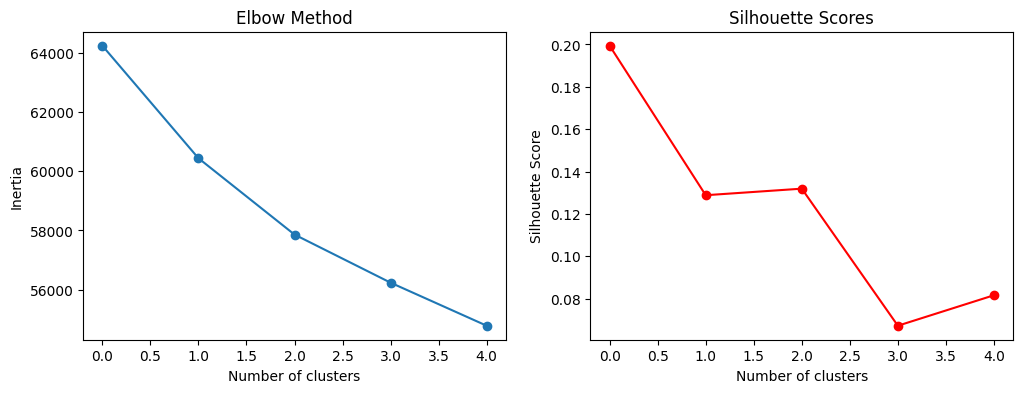

In [29]:
# Plot Elbow Method and Silhouette Scores
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(inertia_list, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(silhouette_list, marker='o', color='red')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()



In [30]:
# Apply KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
print(kmeans)
print(labels_kmeans)


KMeans(n_clusters=3, n_init=10, random_state=42)
[2 0 1 ... 1 1 0]


In [31]:

# Apply Agglomerative Clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)



In [32]:
# Calculate and print Silhouette Scores for both clustering methods
sil_score_kmeans = silhouette_score(X_scaled, labels_kmeans)
sil_score_agg = silhouette_score(X_scaled, labels_agg)
print("KMeans Silhouette Score:", sil_score_kmeans)
print("Hierarchical Silhouette Score:", sil_score_agg)


KMeans Silhouette Score: 0.1288239616736046
Hierarchical Silhouette Score: 0.11311080001944883


##The K Means clustering model achieved a silhouette score of 0.128, while the Hierarchical clustering model obtained 0.11311. Both scores are relatively low, indicating that the clusters are not well separated and that many data points may lie close to the boundaries between clusters. Although K Means performs slightly better, the small difference suggests that neither technique captures strong natural groupings within the dataset. This implies that the data may have overlapping features or weak internal structure, making it difficult to form distinct clusters. To improve clustering quality, i will use PCA.

In [33]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = labels_kmeans
df_pca['Hierarchical_Cluster'] = labels_agg


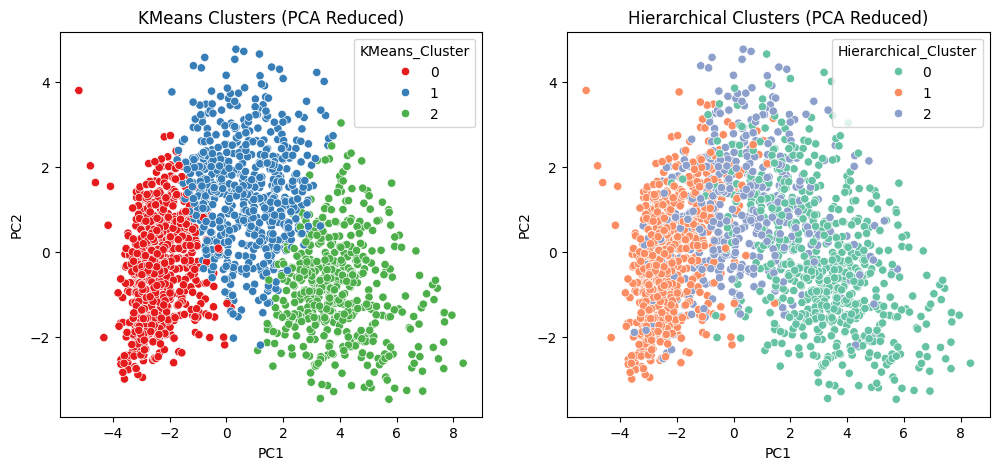

In [34]:
# Visualize the clusters in 2D PCA space
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_pca, palette='Set1')
plt.title("KMeans Clusters (PCA Reduced)")
plt.subplot(1,2,2)
sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', data=df_pca, palette='Set2')
plt.title("Hierarchical Clusters (PCA Reduced)")
plt.show()


##After PCA, K Means forms three clear, compact clusters, showing that dimensionality reduction helped reveal meaningful structure in the data. In contrast, Hierarchical clustering remains mixed, confirming its less effective at capturing separation in this transformed space. This means PCA aligned the data with K Means centroid based logic, improving clarity and cohesion, while Hierarchical clustering still struggles with overlapping boundaries. Overall, K Means + PCA is the stronger pipeline, producing distinct, interpretable clusters and a more reliable segmentation.

In [ ]:
##The best performing model is the K Means clustering model after PCA, which produced three clear and interpretable customer segments. In production, this model would be integrated into a company’s analytics pipeline to automatically assign new customers to one of the three segments. These segments could then drive personalized marketing, targeted promotions, or customer lifecycle strategies.
Potential Deployment Challenges
Even though clustering models are generally lightweight, deploying them at scale can introduce several challenges:
- 	Latency: Real time customer classification ( during signup or purchase) requires fast inference. If PCA transformation and clustering are applied on large incoming batches, processing delays may occur.
-	Scalability: As customer volume grows, the system must handle thousands of new data points daily. PCA and K Means are efficient, but repeated transformations and assignments can strain resources if not optimized.
-	Maintenance: Customer behavior evolves over time. The original clusters may become outdated, leading to
-	poor segmentation quality. The model must be retrained periodically to remain relevant.
-	Data Drift: New customer patterns may not fit the original clusters, causing misclassification or cluster imbalance.
Monitoring and Updating Strategy
To ensure long term reliability, the deployed model should be continuously monitored and updated:
-	Cluster Stability Monitoring: Track metrics such as silhouette score, cluster size distribution, and distance to centroids. Sudden changes indicate data drift.
-	Segment Behavior Tracking: Monitor how each cluster behaves over time (spending habits, frequency, churn). If segments stop being meaningful, retraining is required.
-	Scheduled Retraining: Retrain the PCA + K Means pipeline monthly or quarterly using the latest customer data. Compare new clusters with historical ones to detect shifts.



##colab link https://colab.research.google.com/drive/1Z1pXaywAtSIkzQShgcWv6ENRHXO6i_yJ?usp=sharing